In [1]:
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("GPU Memory Growth ถูกเปิดใช้งานเรียบร้อยแล้ว")
    except RuntimeError as e:
        print(e) 
        

2025-11-13 09:02:55.118226: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-13 09:02:55.131854: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-13 09:02:55.147479: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-13 09:02:55.152447: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-13 09:02:55.164972: I tensorflow/core/platform/cpu_feature_guar

GPU Memory Growth ถูกเปิดใช้งานเรียบร้อยแล้ว


I0000 00:00:1763024577.215543   34821 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1763024577.280144   34821 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1763024577.280191   34821 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
import numpy as np
import cv2
from os import listdir
from os.path import isfile, join
from tqdm import tqdm
import tensorflow as tf
from keras.models import Sequential , load_model
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from keras.applications import MobileNetV2
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.image import ImageDataGenerator
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available:  1
2.17.0


(<Axes: >, <matplotlib.image.AxesImage at 0x7fa3626ab5c0>)

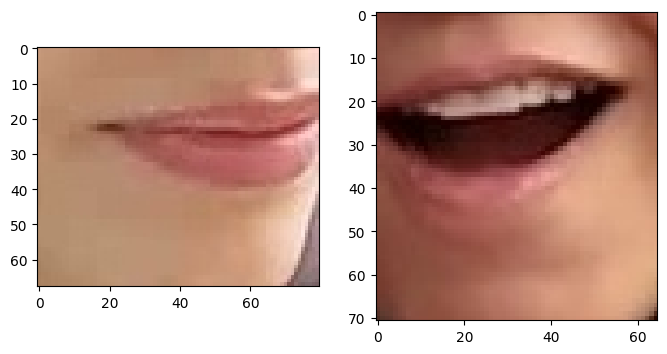

In [3]:
img1 = cv2.imread('assets/images/train/no-yawn/2760.jpg')
img1 = cv2.cvtColor(img1 , cv2.COLOR_BGR2RGB)

img2 = cv2.imread('assets/images/train/yawn/1.jpg')
img2 = cv2.cvtColor(img2 , cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,4))
plt.subplot(121),plt.imshow(img1)
plt.subplot(122),plt.imshow(img2)

In [4]:
width = 128
num_classes = 2
trainpath = 'assets/images/train/'
testpath = 'assets/images/test/'
trainImg = [trainpath+f for f in listdir(trainpath)]
testImg = [testpath+f for f in listdir(testpath)]
img_size = 128
batch_size = 16

In [5]:
# class GrayImageDataGenerator(Sequence):
#     def __init__(self, generator):
#         self.generator = generator

#     def __len__(self):
#         return len(self.generator)

#     def __getitem__(self, i):
#         x_batch, y_batch = self.generator[i]
#         x_batch_gray = np.expand_dims(np.mean(x_batch, axis=-1), axis=-1)
#         return x_batch_gray, y_batch
    

def plotImageFromDataset(dataset, class_names=None):
    # ดึง batch แรกจาก dataset
    for x_batch, y_batch in dataset.take(1):
        x_batch = x_batch.numpy()
        y_batch = y_batch.numpy()
        
        # ถ้า label เป็น one-hot ให้แปลงกลับเป็น index
        if len(y_batch.shape) > 1 and y_batch.shape[1] > 1:
            y_batch = np.argmax(y_batch, axis=1)
        
        print("Batch shape:", x_batch.shape)
        print("Labels:", y_batch[:10])
        
        plt.figure(figsize=(8, 8))
        for i in range(9):
            plt.subplot(3, 3, i + 1)
            
            img = x_batch[i]
            # รองรับ grayscale และ RGB
            plt.imshow(img, cmap='gray')
            
            if class_names is not None:
                title = class_names[int(y_batch[i])]
            else:
                title = f"Label: {int(y_batch[i])}"
            plt.title(title)
            plt.axis('off')
        plt.tight_layout()
        plt.show()
        break  # แสดงแค่ batch แรก
    

def img2data(path):
    rawImgs = []
    labels = []
    i=0
    for imagePath in (path):
        for item in tqdm(listdir(imagePath)):
            
            if i == 8000 and  (np.where(imagePath == trainpath) or np.where(imagePath == testpath)):
                return rawImgs, labels
                        
            file = join(imagePath, item)
            if file[-1] =='g':
                img = cv2.imread(file , cv2.COLOR_BGR2RGB)
                img = cv2.resize(img ,(width,width))
                rawImgs.append(img)
                
                l = imagePath.split('/')[-1]
                if l == 'no-yawn':
                    labels.append([1,0])         
                elif l == 'yawn':
                    labels.append([0,1])
                i+=1    
            
    return rawImgs, labels


def rgb2gray(images):
    grayImgs = []
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        grayImgs.append(gray)
    print(grayImgs[0].shape)
    
    return grayImgs

Found 5119 files belonging to 2 classes.
Using 4096 files for training.


I0000 00:00:1763024578.206920   34821 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1763024578.206982   34821 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1763024578.206994   34821 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1763024578.323495   34821 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1763024578.323555   34821 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-11-13

Found 1080 files belonging to 2 classes.
Using 216 files for validation.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.5857544..253.76917].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.015625..240.80469].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.9708862..230.49524].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..254.69174].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..253.5498].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [25.61232..255.0].
Clipping input data t

Batch shape: (16, 128, 128, 3)
Labels: [0 0 0 0 0 1 0 0 1 1]


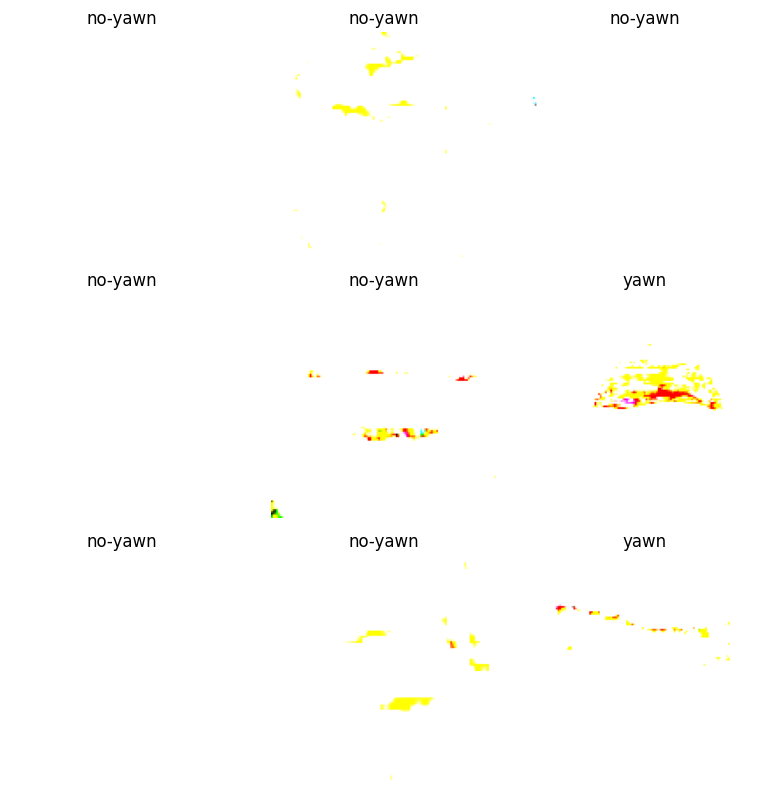

In [6]:
imagePath = 'assets/images/train/'
testPath = 'assets/images/test/'

train_ds = tf.keras.utils.image_dataset_from_directory(
    imagePath,
    labels='inferred',
    label_mode='categorical',
    image_size=(img_size, img_size),
    batch_size=batch_size,
    validation_split=0.2,
    subset='training',
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    testPath,
    labels='inferred',
    label_mode='categorical',
    image_size=(img_size, img_size),
    batch_size=batch_size,
    validation_split=0.2,
    subset='validation',
    seed=123
)

plotImageFromDataset(train_ds,train_ds.class_names)

# train_generator_gray = GrayImageDataGenerator(train_generator)

# train_generator_gray.plotImageFormDatagen()

In [7]:
model = Sequential()

model.add(Conv2D(256, (3, 3), activation="relu", input_shape=(img_size,img_size,1)))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.2))

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(32, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Flatten())
model.add(Dropout(0.5))

model.add(Dense(256, activation="relu"))
model.add(Dense(2, activation="softmax"))

model.compile(loss="categorical_crossentropy", metrics=["accuracy"], optimizer="adam")

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 256)  │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,978 (2.18 MB)

 Trainable params: 570,978 (2.18 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    train_ds,                # Pass training labels as 'y'
    batch_size=8,
    epochs=50,
    validation_data=(val_ds), # validation_data remains a tuple (X_val, Y_val)
    shuffle=True,
    callbacks=[EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)]
)

Epoch 1/50


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "conv2d" is incompatible with the layer: expected axis -1 of input shape to have value 1, but received input with shape (None, 128, 128, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 128, 128, 3), dtype=float32)
  • training=True
  • mask=None